# Receitas

Para obter os dados de receitas dos município, acessamos o Portal de Dados Abertos da Prefeitura. No menu do canto esquerdo, navegue até "Dados Abertos":

![portal_dados_abertos](../assets/cityhall_assets/portal_dados_abertos_prefeitura.png)

Ao selecionarmo "Receitas Orçamentárias", na barra roxa, somos direcionados para a página da api do portal: 

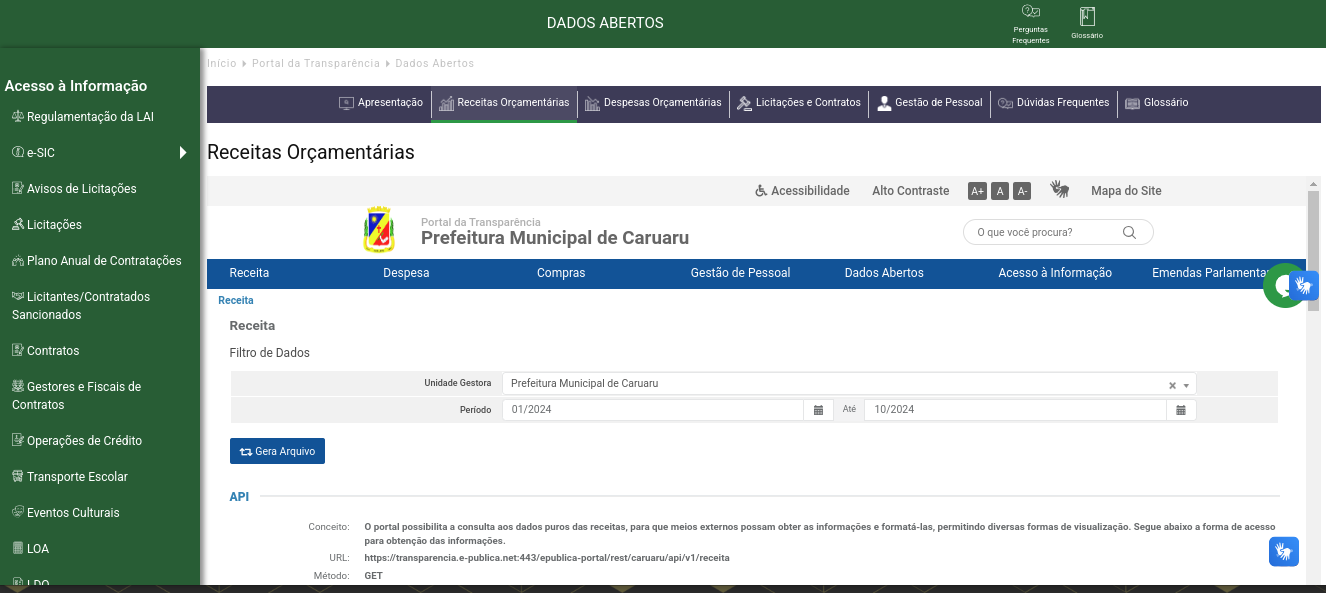

Nesta página, nos interessa saber como interagimos com a API para obter os registros que desejamos.

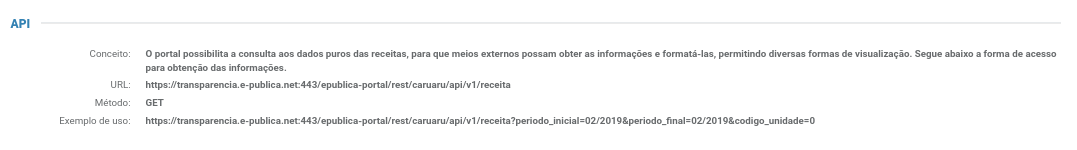

De pronto observamos que precisamos fornecer alguns parâmetros: `periodo_inicial`, `periodo_final` e `codigo_unidade`. Podemos checar o código da unidade gestora na tabela disponível na mesma página. Para testarmos, vamos passar o código da Prefeitura Municipal, 2.

In [18]:
import os
import requests
import json
import pandas as pd

In [19]:
periodo_inicial = '01/2024'
periodo_final = '10/2024'
codigo_unidade = '2'

In [20]:
url = f'https://transparencia.e-publica.net/epublica-portal/rest/caruaru/api/v1/receita?periodo_inicial={periodo_inicial}&periodo_final={periodo_final}&codigo_unidade={codigo_unidade}'

In [21]:
resp = requests.get(url)

In [22]:
resp

<Response [202]>

In [23]:
data = resp.json()

In [24]:
data.keys()

dict_keys(['informacao', 'ultimaAtualizacao', 'totalRegistros', 'registros'])

In [25]:
total_registros = data['registros']

In [26]:
len(total_registros)

11

In [27]:
total_registros[:2]

[{'registro': {'receita': {'codigo': 251, 'tipoReceita': 'Bruta'},
   'unidadeGestora': {'codigo': 43006,
    'denominacao': 'Fundação de Cultura de Caruaru'},
   'naturezaReceita': {'categoriaEconomica': {'codigo': '100000000000',
     'denominacao': 'Receitas Correntes'},
    'origem': {'codigo': '170000000000',
     'denominacao': 'Transferências Correntes'},
    'especie': {'codigo': '172000000000',
     'denominacao': 'Transferências dos Estados e do Distrito Federal e de suas Entidades'},
    'rubrica': {'codigo': '172400000000',
     'denominacao': 'Transferências de Convênios dos Estados e DF e de Suas Entidades'},
    'alinea': {'codigo': '172499000000',
     'denominacao': 'Outras Transferências de Convênios dos Estados e DF e de Suas Entidades'},
    'subalinea': {'codigo': '172499000000',
     'denominacao': 'Outras Transferências de Convênios dos Estados e DF e de Suas Entidades'},
    'subdetalhamento1': {'codigo': '172499010000',
     'denominacao': 'Outras Transferência

A estrutura aninhada dos dados pode ser difícil de ler a princípio. Cada bloco desse corresponde a um registro de receita com várias informações realacionadas. Abaixo segue um diagrama para entendermor os dados:

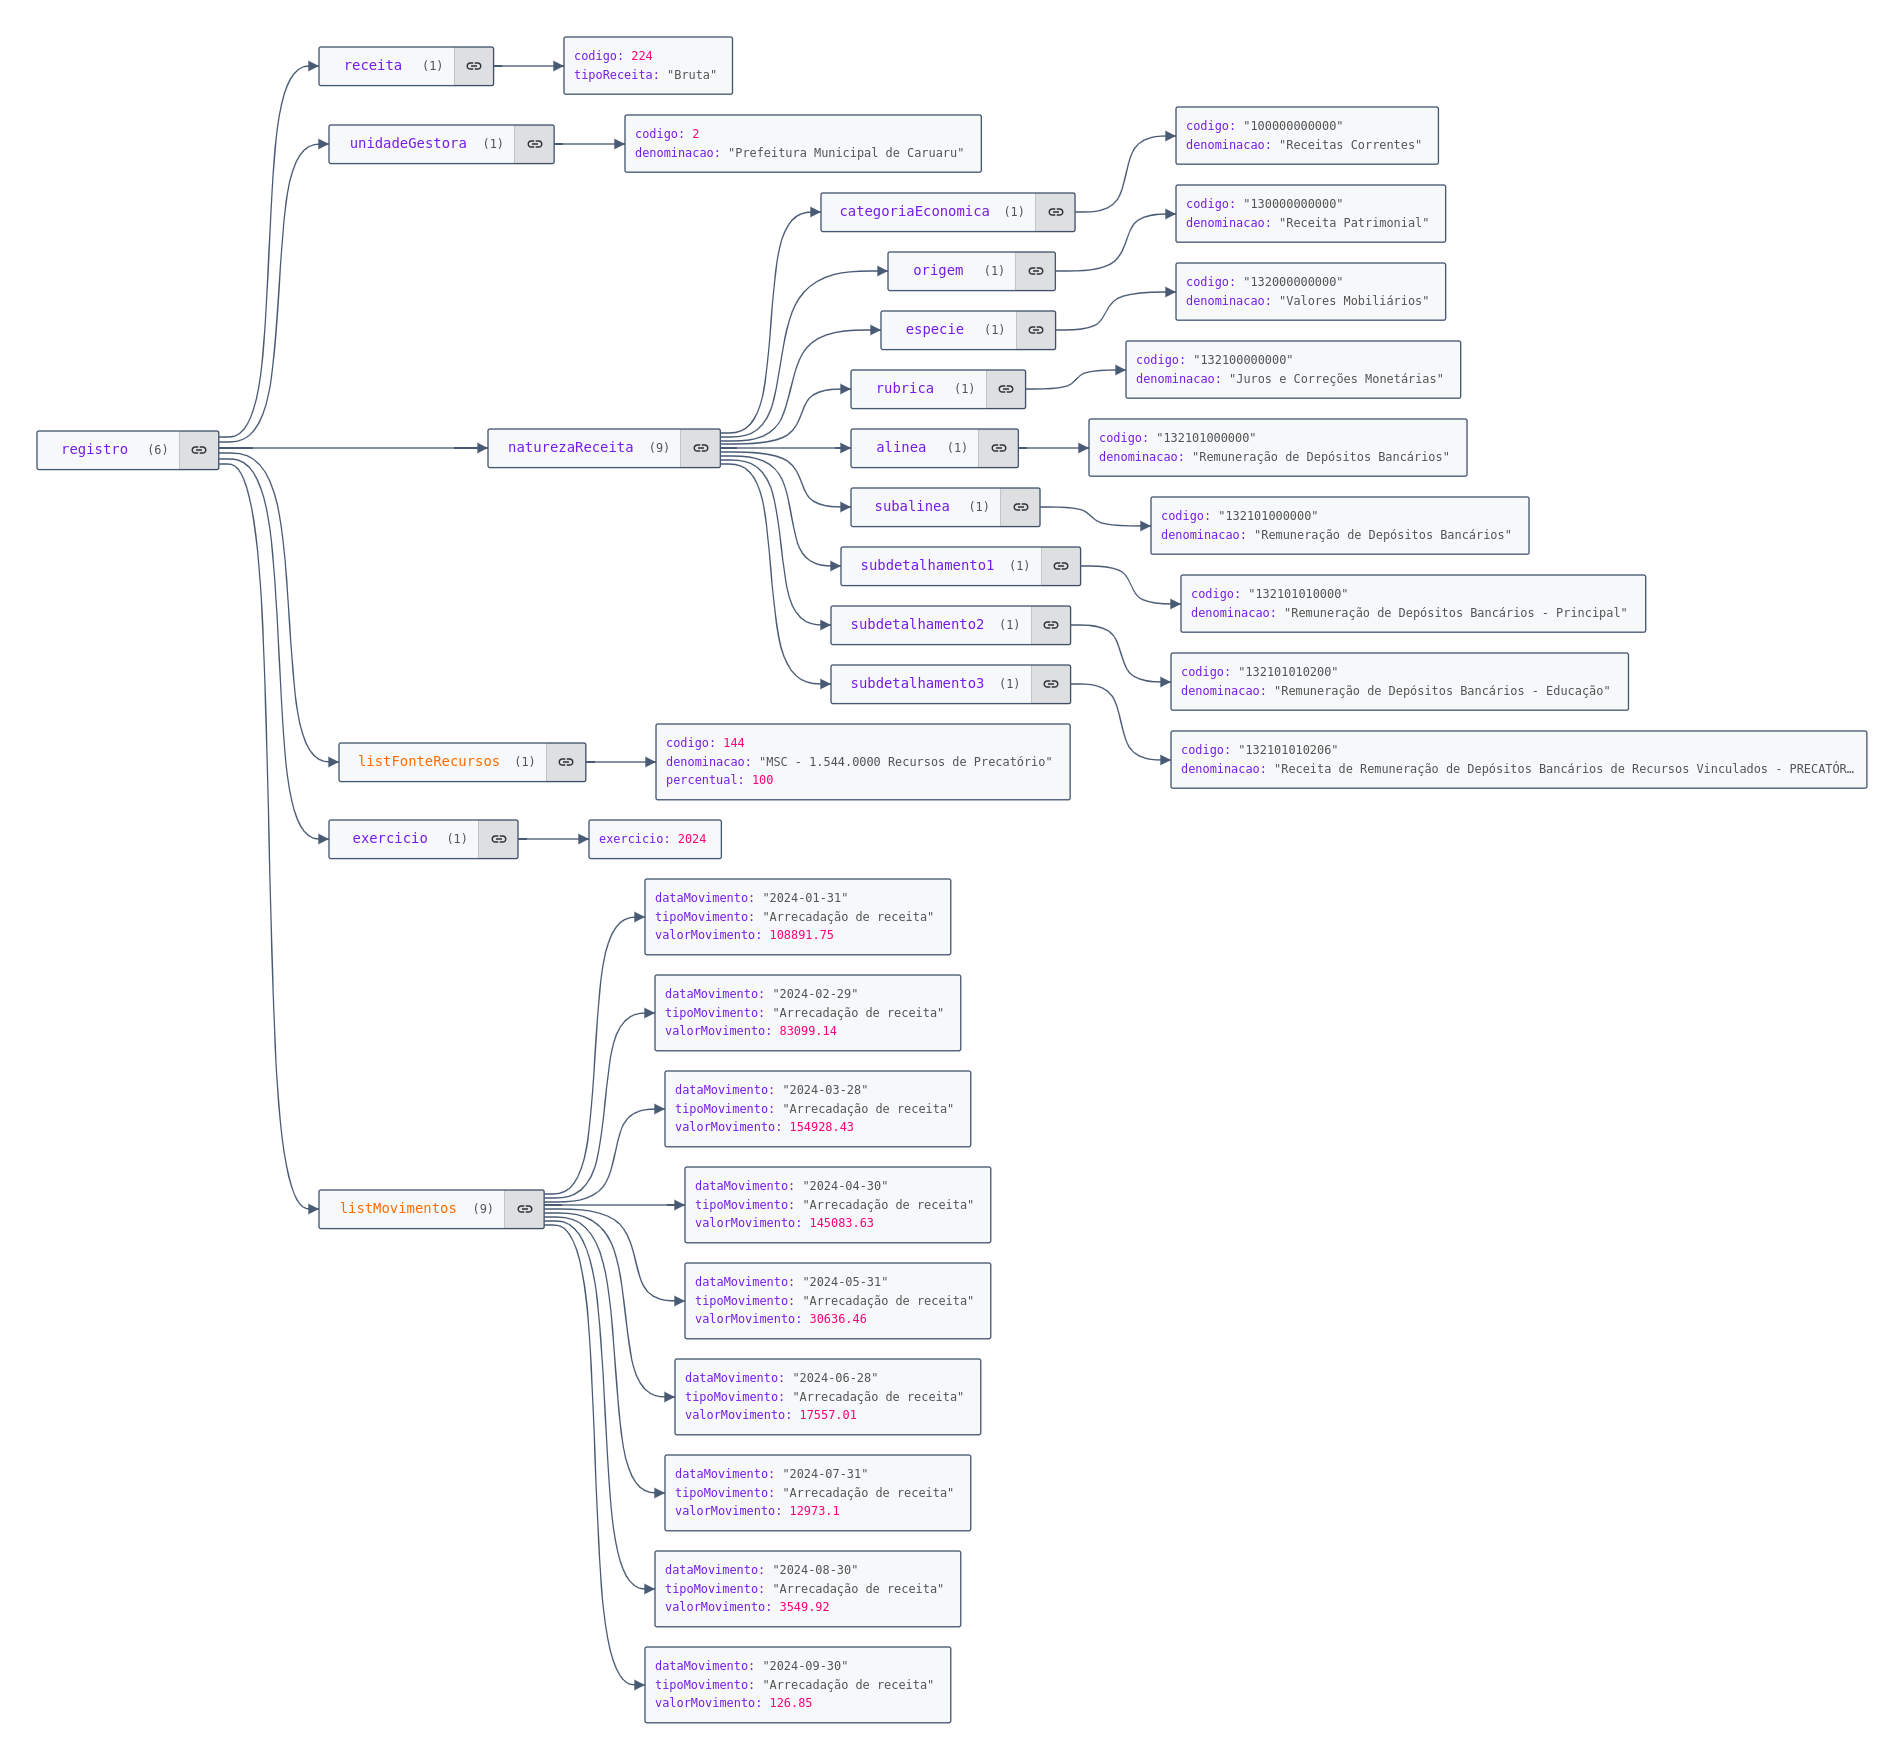

Os dados apresentados representam informações detalhadas sobre receitas públicas arrecadadas por uma unidade gestora, no caso, pegamos como exemplo a Prefeitura Municipal de Caruaru. A estrutura está organizada em múltiplos níveis, abrangendo detalhes sobre o tipo de receita, a natureza dessa arrecadação, as fontes de recursos, os movimentos financeiros associados e o exercício fiscal correspondente. A seguir, a descrição de cada componente:

1. **Receita**
    - **Código da Receita**: Um identificador único associado à receita específica (exemplo: 224 e 258).
    - **Tipo de Receita**: Classifica a receita como "Bruta", indicando que não foi subtraída nenhuma dedução ou despesa associada.
2. **Unidade Gestora**
    - **Código da Unidade Gestora**: Um código que identifica a unidade responsável pela arrecadação (neste caso, 2 para a Prefeitura Municipal de Caruaru).
    - **Denominação da Unidade Gestora**: Nome oficial da unidade gestora, que no exemplo é a "Prefeitura Municipal de Caruaru".
4. **Natureza da Receita**:

A natureza da receita é descrita em múltiplos níveis hierárquicos que detalham sua origem e finalidade. Os dados estão organizados da seguinte maneira:

- **Categoria Econômica**: Refere-se ao tipo mais amplo de receita. Exemplos incluem "Receitas Correntes" e "Receitas de Capital".
- **Origem**: Detalha a origem da receita, como "Receita Patrimonial" ou "Transferências de Capital".
- **Espécie**: Define a subcategoria da receita, como "Valores Mobiliários" ou "Transferências da União e de suas Entidades".
- **Rubrica**: Representa uma subdivisão ainda mais específica da espécie, como "Juros e Correções Monetárias".
- **Alinea**: Detalha ainda mais a rubrica, como "Remuneração de Depósitos Bancários".
- **Subalínea e Subdetalhamentos**: Refina ainda mais as classificações anteriores, fornecendo uma descrição minuciosa, como "Remuneração de Depósitos Bancários - Principal" ou "Emendas Parlamentares - Bancada - PMC".

5. **Fontes de Recursos**
- **Código da Fonte de Recursos**: Um identificador que representa a origem dos fundos utilizados, como 144 ou 148.
- **Denominação da Fonte de Recursos**: Descreve a origem do recurso, como "Recursos de Precatório" ou "Emendas Parlamentares de Bancada - União".
- **Percentual**: Representa a porcentagem do recurso que foi utilizado ou arrecadado, normalmente 100%.

6. **Exercício**
- **Exercício Fiscal**: Representa o ano de referência para a arrecadação da receita, como o exercício fiscal de 2024.

7. **Movimentos Financeiros**
- **Data do Movimento**: A data em que um movimento financeiro foi realizado, como "2024-01-31" ou "2024-04-16".
- **Tipo de Movimento**: Descreve o tipo de transação, por exemplo, "Arrecadação de receita", indicando que o valor foi efetivamente recebido.
- **Valor do Movimento**: O montante arrecadado em cada transação, que varia entre os exemplos, como 108,891.75 ou 382,000.00.

## Obtendo as receitas de todas as unidades gestoras

Para nos auxiliar, usarei o dicionário associando a unidade gestora com seu respectivo código: 

In [34]:
path_base = os.getcwd()
file = 'codigo_unidades.csv'
file_path = os.path.join(path_base, file)

df_unidades = pd.read_csv(file_path)

df_unidades.head(20)

,cod_unidade_gestora,nome_unidade_gestora
0,2,Prefeitura Municipal de Caruaru
1,3,Consórcio dos Municípios Pernambucanos - COMUPE
2,4,CONIAPE - Consórcio Público Intermunicipal do ...
3,3012,CARUARUPREV - FUNDO PREVIDENCIÁRIO
4,43002,Câmara Municipal de Vereadores de Caruaru
5,43006,Fundação de Cultura de Caruaru
6,43008,Fundo Municipal de Saúde de Caruaru
7,43009,Fundo Municipal da Criança e Adolescente de Ca...
8,43010,Fundo Municipal de Assistência Social de Caruaru
9,43012,CARUARUPREV


### Função para obter dados de todas as unidades gestoras

Vamos implementar um script que irá obter os dados de cada unidade gestora e os gravará em seus respectivos arquivos .json: 

In [50]:
# Definir o diretório onde os arquivos JSON serão salvos
receitas_dir = os.path.join(path_base, 'receitas')

# Criar o diretório 'receitas' se ele não existir
if not os.path.exists(receitas_dir):
    os.makedirs(receitas_dir)

# Função para obter as receitas de todas as unidades gestoras e salvar cada uma em um arquivo JSON separado
def obter_receitas_unidades(unidades, periodo_inicial, periodo_final):
    for _, unidade in unidades.iterrows():
        codigo_unidade = unidade['cod_unidade_gestora']
        nome_unidade = unidade['nome_unidade_gestora']
        
        url = f'https://transparencia.e-publica.net/epublica-portal/rest/caruaru/api/v1/receita?periodo_inicial={periodo_inicial}&periodo_final={periodo_final}&codigo_unidade={codigo_unidade}'
        
        try:
            response = requests.get(url)
            response.raise_for_status()  # Verifica se houve erro na requisição
            
            data = response.json()  # Obter os dados da resposta em JSON
            
            # Verifica se os dados retornados são válidos
            if isinstance(data, (dict, list)):
                # Definir o nome do arquivo JSON para a unidade
                file_name = f"receitas_unidade_{codigo_unidade}.json"
                file_path = os.path.join(receitas_dir, file_name)
                
                # Salvar os dados da unidade em um arquivo JSON separado
                with open(file_path, 'w', encoding='utf-8') as json_file:
                    json.dump(data, json_file, ensure_ascii=False, indent=4)
                
                print(f"Dados da unidade {codigo_unidade} ({nome_unidade}) salvos em '{file_path}'.")
            else:
                print(f"Formato inesperado de dados para a unidade {codigo_unidade}.")
        
        except requests.exceptions.RequestException as e:
            print(f"Erro ao obter dados para a unidade {codigo_unidade}: {e}")

# Executar a função
obter_receitas_unidades(df_unidades, periodo_inicial, periodo_final)

Dados da unidade 2 (Prefeitura Municipal de Caruaru) salvos em '/home/tiago/Workspace/projetos/mutuca/docs/prefeitura_municipal/receitas/receitas_unidade_2.json'.
Dados da unidade 3 (Consórcio dos Municípios Pernambucanos - COMUPE) salvos em '/home/tiago/Workspace/projetos/mutuca/docs/prefeitura_municipal/receitas/receitas_unidade_3.json'.
Dados da unidade 4 (CONIAPE - Consórcio Público Intermunicipal do Agreste Pernambucano e Fronteiras) salvos em '/home/tiago/Workspace/projetos/mutuca/docs/prefeitura_municipal/receitas/receitas_unidade_4.json'.
Dados da unidade 3012 (CARUARUPREV - FUNDO PREVIDENCIÁRIO) salvos em '/home/tiago/Workspace/projetos/mutuca/docs/prefeitura_municipal/receitas/receitas_unidade_3012.json'.
Dados da unidade 43002 (Câmara Municipal de Vereadores de Caruaru) salvos em '/home/tiago/Workspace/projetos/mutuca/docs/prefeitura_municipal/receitas/receitas_unidade_43002.json'.
Dados da unidade 43006 (Fundação de Cultura de Caruaru) salvos em '/home/tiago/Workspace/proje

Com o código acima, temos a lógica para implementar o crawler que irá automatizar a extração. 